# BEST DENSITIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define the directory you want to search in
directory = Path(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\coe_results"
)
files = [
    file for file in directory.rglob("*") if file.is_file() and "times" not in file.name
]

In [2]:
best_strategy = {
    "BTC_USD": {
        "univariate_hawkes": "training_time_900",
        "multivariate_hawkes": "training_time_1500",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "real_time",
    },
    "BTC_USDT": {
        "univariate_hawkes": "training_time_900",
        "multivariate_hawkes": "training_time_1500",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "real_time",
    },
    "ETH_BTC": {
        "univariate_hawkes": "training_time_900",
        "multivariate_hawkes": "training_time_1500",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "real_time",
    },
    "ETH_USD": {
        "univariate_hawkes": "training_time_900",
        "multivariate_hawkes": "training_time_1500",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "real_time",
    },
    "ETH_USDT": {
        "univariate_hawkes": "training_time_900",
        "multivariate_hawkes": "training_time_1500",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "real_time",
    },
}

In [3]:
def same_sign(a, b):
    return (a >= 0 and b >= 0) or (a < 0 and b < 0)


dfs = []
for file in files:
    fileparts = file.parts
    method = fileparts[-5]
    pair = fileparts[-4]
    param = fileparts[-3]
    bi_level = fileparts[-2]
    filename = fileparts[-1]

    if best_strategy[pair][method] != param:
        continue

    prediction_df = pd.read_csv(file, sep="\t")
    if method == "oracle":
        real_df = pd.read_csv(
            f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\simulation_dataframes\\multivariate_hawkes\\{pair}\\training_time_1500\\120\\{bi_level}\\{filename}",
            sep="\t",
        )
    else:
        real_df = pd.read_csv(
            f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\simulation_dataframes\\{method}\\{pair}\\{param}\\120\\{bi_level}\\{filename}",
            sep="\t",
        )
    comparison_df = real_df.merge(prediction_df, left_on="real", right_on="time")
    comparison_df = comparison_df.dropna()

    comparison_df["sign_predicted"] = comparison_df[
        ["predicted_return", "Return"]
    ].apply(lambda x: same_sign(x["predicted_return"], x["Return"]), axis=1)

    if (
        filename == "orderbook_changes_1705364671663_1705361143.tsv"
        and bi_level == "bi_level_5"
    ):
        df_hawkes_coe_file = comparison_df.copy()
        df_hawkes_coe_file["method"] = method
        df_hawkes_coe_file["pair"] = pair
        df_hawkes_coe_file["param"] = param
        df_hawkes_coe_file["bi_level"] = bi_level
        df_hawkes_coe_file["filename"] = filename

    df = comparison_df[["sign_predicted", "Return"]].copy()
    df["method"] = method
    df["pair"] = pair
    df["param"] = param
    df["bi_level"] = bi_level
    df["filename"] = filename

    dfs.append(df)

df = pd.concat(dfs)
df = df[df["bi_level"] == "bi_level_5"]
df.head()

,sign_predicted,Return,method,pair,param,bi_level,filename
0,1.0,-0.000047,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
1,1.0,-0.000082,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
2,1.0,-0.000070,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
3,0.0,0.000012,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
4,1.0,0.000035,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv


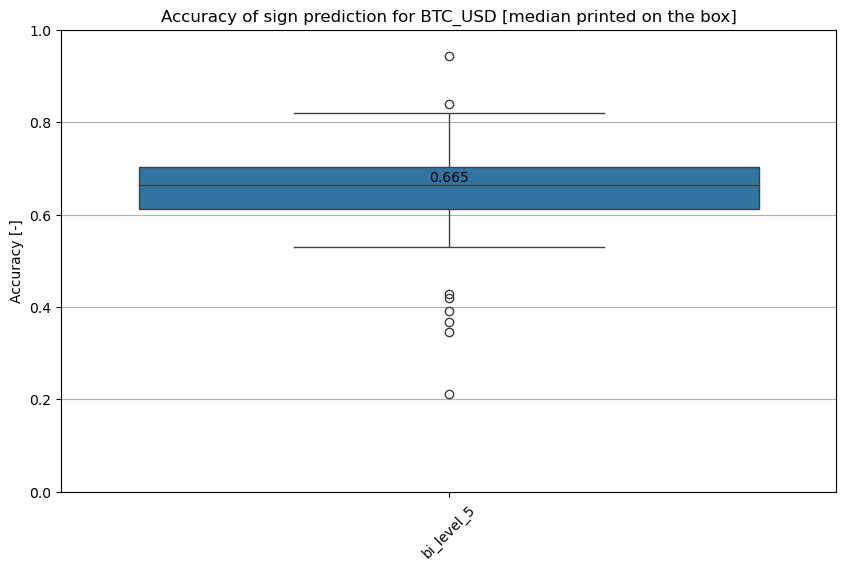

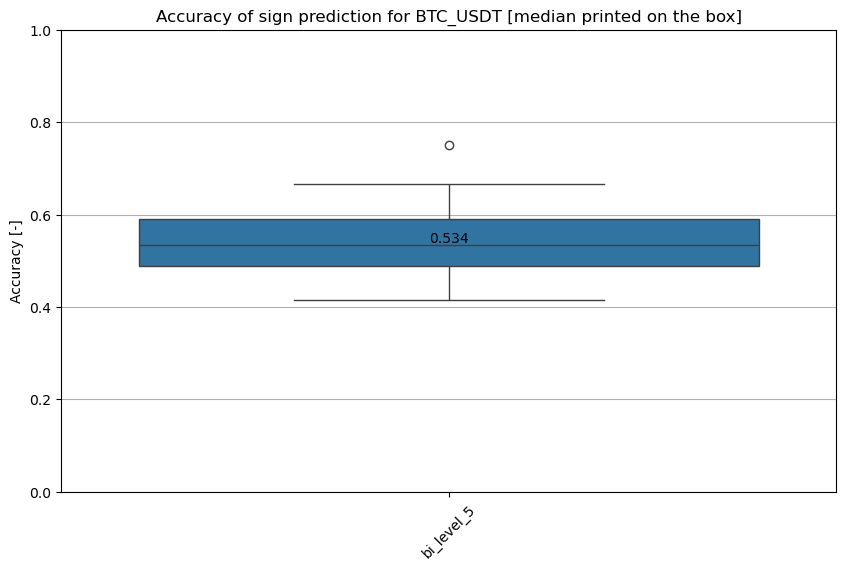

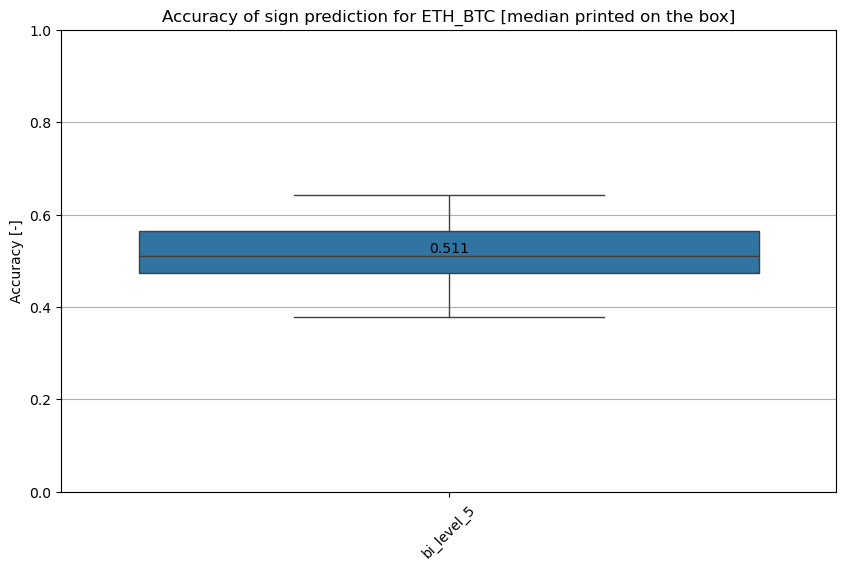

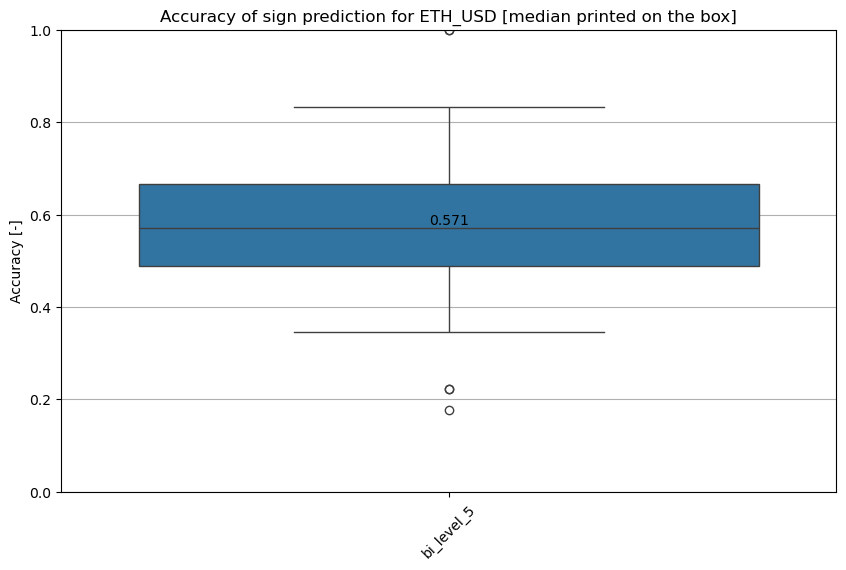

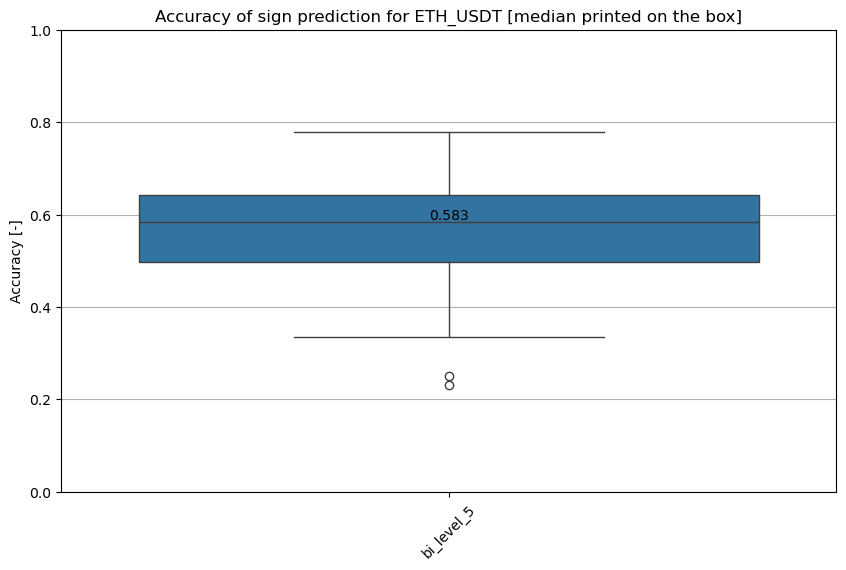

In [4]:
df_bi = df[df["method"] == "multivariate_hawkes"]
for pair in df_bi["pair"].unique():
    df_pair = df_bi[df_bi["pair"] == pair]
    df_accuracy = (
        df_pair[["bi_level", "sign_predicted", "filename"]]
        .groupby(["bi_level", "filename"])
        .mean()
    )
    df_accuracy = df_accuracy.reset_index()

    plt.figure(figsize=(10, 6))
    sns.boxplot(x="bi_level", y="sign_predicted", data=df_accuracy)
    # print median accuracy
    for i, method in enumerate(df_accuracy["bi_level"].unique()):
        median_accuracy = df_accuracy[df_accuracy["bi_level"] == method][
            "sign_predicted"
        ].median()

        plt.text(i, median_accuracy, f"{median_accuracy:.3f}", ha="center", va="bottom")
    plt.title(f"Accuracy of sign prediction for {pair} [median printed on the box]")
    plt.grid(axis="y")
    plt.ylim(0, 1)
    plt.ylabel("Accuracy [-]")
    plt.xlabel("")
    # rotate x labels
    plt.xticks(rotation=45)

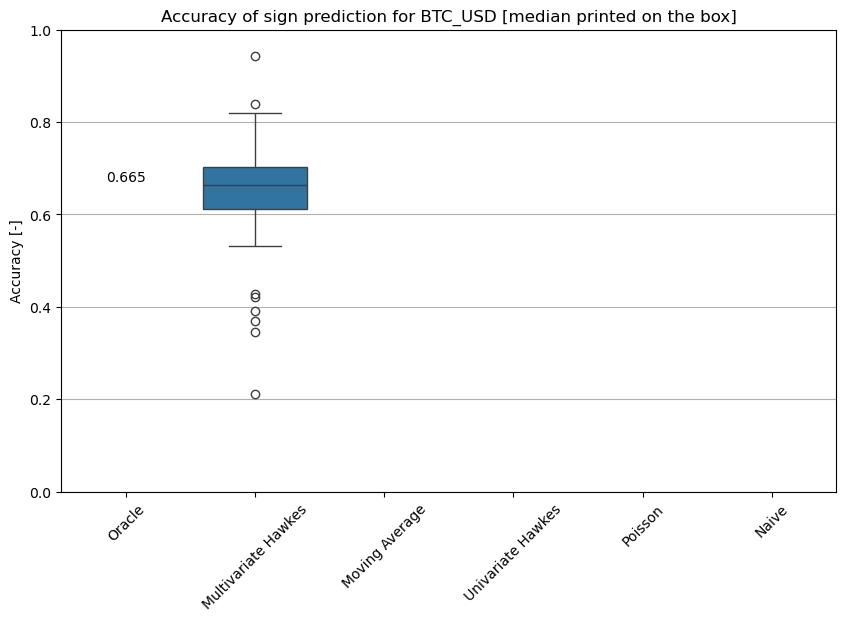

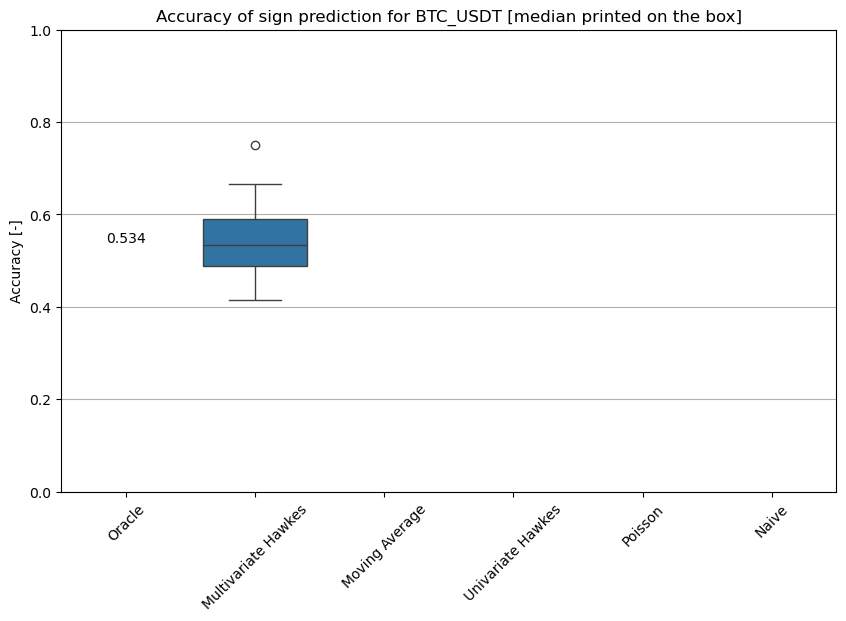

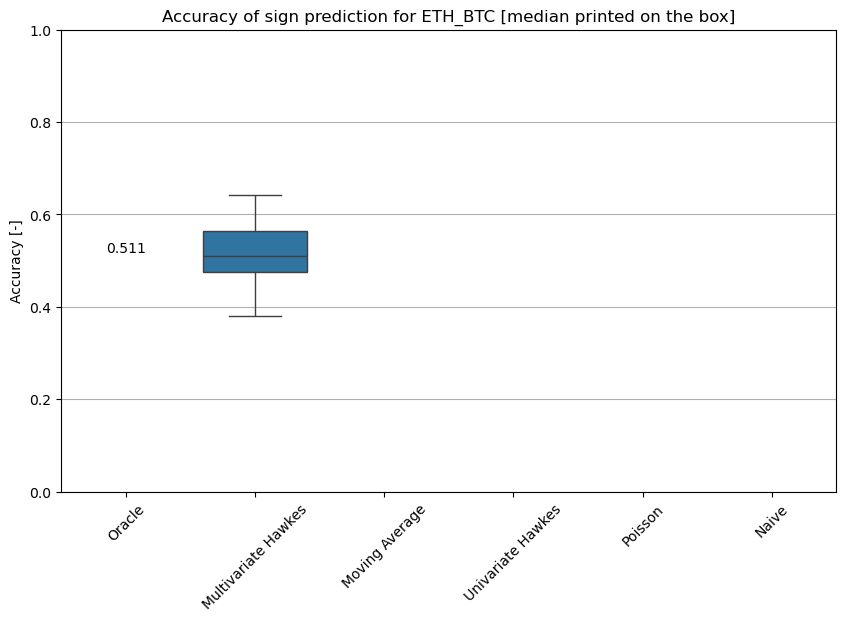

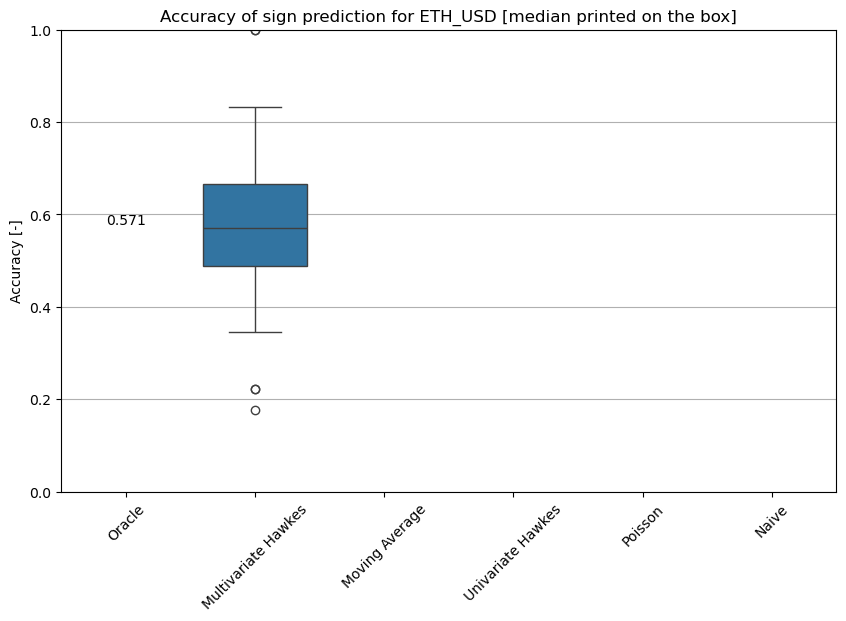

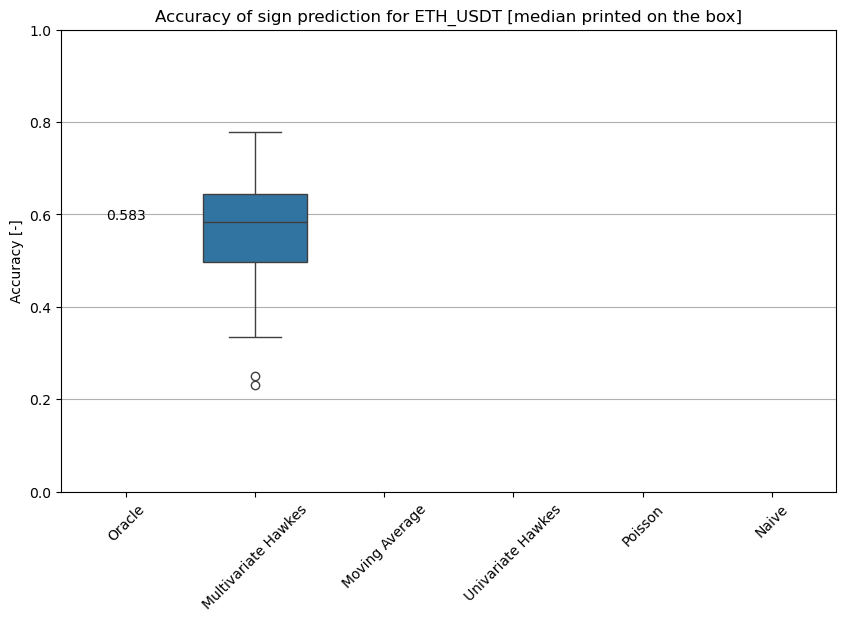

In [5]:
for pair in df["pair"].unique():
    df_pair = df[df["pair"] == pair]
    df_accuracy = (
        df_pair[["method", "sign_predicted", "filename"]]
        .groupby(["method", "filename"])
        .mean()
    )
    df_accuracy = df_accuracy.reset_index()

    df_accuracy["method"] = df_accuracy["method"].replace(
        {
            "univariate_hawkes": "Univariate Hawkes",
            "multivariate_hawkes": "Multivariate Hawkes",
            "moving_average": "Moving Average",
            "poisson": "Poisson",
            "naive": "Naive",
            "oracle": "Oracle",
        }
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x="method",
        y="sign_predicted",
        data=df_accuracy,
        order=[
            "Oracle",
            "Multivariate Hawkes",
            "Moving Average",
            "Univariate Hawkes",
            "Poisson",
            "Naive",
        ],
    )
    # print median accuracy
    for i, method in enumerate(df_accuracy["method"].unique()):
        median_accuracy = df_accuracy[df_accuracy["method"] == method][
            "sign_predicted"
        ].median()

        plt.text(i, median_accuracy, f"{median_accuracy:.3f}", ha="center", va="bottom")
    plt.title(f"Accuracy of sign prediction for {pair} [median printed on the box]")
    plt.grid(axis="y")
    plt.ylim(0, 1)
    plt.ylabel("Accuracy [-]")
    plt.xlabel("")
    # rotate x labels
    plt.xticks(rotation=45)

In [6]:
df_accuracy = (
    df[["pair", "method", "sign_predicted", "filename"]]
    .groupby(["pair", "method", "filename"])
    .mean()
).reset_index()
df_accuracy = df_accuracy[df_accuracy["method"] == "multivariate_hawkes"]
df_accuracy["method"] = "Hawkes+COE"
df_accuracy.columns = ["Pair", "Method", "file", "Accuracy"]
df_accuracy.head()

,Pair,Method,file,Accuracy
0,BTC_USD,Hawkes+COE,orderbook_changes_1705356920082_1705353321.tsv,0.692308
1,BTC_USD,Hawkes+COE,orderbook_changes_1705356920082_1705353442.tsv,0.615385
2,BTC_USD,Hawkes+COE,orderbook_changes_1705356920082_1705353563.tsv,0.659574
3,BTC_USD,Hawkes+COE,orderbook_changes_1705356920082_1705353684.tsv,0.716981
4,BTC_USD,Hawkes+COE,orderbook_changes_1705356920082_1705353805.tsv,0.666667


In [7]:
import os


dfs = []

for pair in ["BTC_USD", "ETH_USD", "ETH_BTC", "BTC_USDT", "ETH_USDT"]:
    PATH = f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations_multivariate\\multivariate_hawkes\\{pair}\\training_time_1500\\simulation_seconds_120"
    files = os.listdir(PATH)
    for file in files:
        df = pd.read_csv(os.path.join(PATH, file), sep="\t")
        df["file"] = file
        df["pair"] = pair
        dfs.append(df)

df = pd.concat(dfs)

df["Predicted Event Type"] = df[
    ["Predicted MP UP Time", "Predicted MP DOWN Time"]
].apply(
    lambda x: (
        "MID_PRICE_UP"
        if x["Predicted MP UP Time"] < x["Predicted MP DOWN Time"]
        else "MID_PRICE_DOWN"
    ),
    axis=1,
)
df["Correct Prediction"] = df["Predicted Event Type"] == df["Real Event Type"]
df_hawkes_only_file = df[
    df["file"] == "orderbook_changes_1705364671663_1705361143.tsv"
].copy()
boxplot_df = df[["pair", "file", "Correct Prediction"]].groupby(["pair", "file"]).mean()
boxplot_df = boxplot_df.reset_index()
boxplot_df.columns = ["Pair", "file", "Accuracy"]
boxplot_df["Method"] = "HawkesOnly"
boxplot_df.head()

,Pair,file,Accuracy,Method
0,BTC_USD,orderbook_changes_1705356920082_1705353321.tsv,0.526316,HawkesOnly
1,BTC_USD,orderbook_changes_1705356920082_1705353442.tsv,0.647059,HawkesOnly
2,BTC_USD,orderbook_changes_1705356920082_1705353563.tsv,0.491803,HawkesOnly
3,BTC_USD,orderbook_changes_1705356920082_1705353684.tsv,0.581967,HawkesOnly
4,BTC_USD,orderbook_changes_1705356920082_1705353805.tsv,0.551282,HawkesOnly


In [8]:
import os

dfs = []

for pair in ["BTC_USD", "ETH_USD", "ETH_BTC", "BTC_USDT", "ETH_USDT"]:
    PATH = f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations_multivariate_bi\\multivariate_hawkes\\{pair}\\training_time_1500\\simulation_seconds_120"
    files = os.listdir(PATH)
    for file in files:
        df = pd.read_csv(os.path.join(PATH, file), sep="\t")
        df["file"] = file
        df["pair"] = pair
        dfs.append(df)

df = pd.concat(dfs)

df["Real Event Type MP"] = df["Real Event Type"].apply(lambda x: x.split("_BI_")[0])

df["Predicted Event Type"] = df[
    [
        "Predicted MP UP BI POS Time",
        "Predicted MP DOWN BI POS Time",
        "Predicted MP UP BI NEG Time",
        "Predicted MP DOWN BI NEG Time",
    ]
].idxmin(axis=1)

df["Predicted Event Type"] = df["Predicted Event Type"].apply(
    lambda x: {
        "Predicted MP UP BI POS Time": "MP_UP",
        "Predicted MP DOWN BI POS Time": "MP_DOWN",
        "Predicted MP UP BI NEG Time": "MP_UP",
        "Predicted MP DOWN BI NEG Time": "MP_DOWN",
    }[x]
)

df["Correct Prediction"] = df["Predicted Event Type"] == df["Real Event Type MP"]
df_hawkes_bi_file = df[
    df["file"] == "orderbook_changes_1705364671663_1705361143.tsv"
].copy()
boxplot_df_a = (
    df[["pair", "file", "Correct Prediction"]].groupby(["pair", "file"]).mean()
)
boxplot_df_a = boxplot_df_a.reset_index()
boxplot_df_a.columns = ["Pair", "file", "Accuracy"]
boxplot_df_a["Method"] = "Hawkes+BI"
boxplot_df_a.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21324\1923679418.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs)


,Pair,file,Accuracy,Method
0,BTC_USD,orderbook_changes_1705356920082_1705353321.tsv,0.523810,Hawkes+BI
1,BTC_USD,orderbook_changes_1705356920082_1705353442.tsv,0.571429,Hawkes+BI
2,BTC_USD,orderbook_changes_1705356920082_1705353563.tsv,0.372549,Hawkes+BI
3,BTC_USD,orderbook_changes_1705356920082_1705353684.tsv,0.519608,Hawkes+BI
4,BTC_USD,orderbook_changes_1705356920082_1705353805.tsv,0.464286,Hawkes+BI


In [9]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

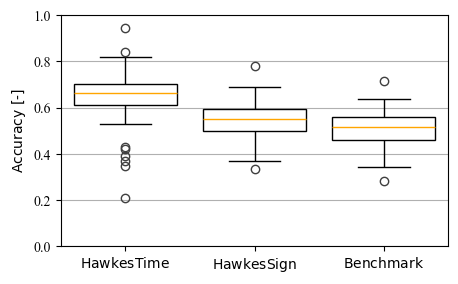

In [12]:
df_final = pd.concat(
    [boxplot_df, df_accuracy, df_accuracy_benchmark], ignore_index=True
)

# put order on Method
df_final = df_final.sort_values(
    by=["Method"],
    key=lambda x: x.map(
        {
            "HawkesOnly": 1,
            "Benchmark": 2,
            "Hawkes+COE": 0,
        }
    ),
)

df_final = df_final[df_final["Pair"] == "BTC_USD"]


plt.figure(figsize=(5, 3))
sns.boxplot(
    x="Method",
    y="Accuracy",
    data=df_final,
    boxprops=dict(facecolor="white", edgecolor="black"),  # Box color and black edges
    whiskerprops=dict(color="black"),  # Whisker color
    capprops=dict(color="black"),  # Caps color
    medianprops=dict(color="orange"),
)  # Median line color


plt.grid(axis="y")
plt.ylim(0, 1)
plt.ylabel(r"$\text{Accuracy [-]}$")
plt.xlabel("")
plt.xticks(
    [0, 1, 2],
    [r"$\text{HawkesTime}$", r"$\text{HawkesSign}$", r"$\text{Benchmark}$"],
)
# rotate x labels
plt.savefig(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\images\\accuracy.eps",
    format="eps",
    bbox_inches="tight",
)

plt.show()

In [34]:
df_final[["Method", "Pair", "Accuracy"]].groupby(["Method", "Pair"]).mean()

,,Accuracy
Method,Pair,
Benchmark,BTC_USD,0.513624
Hawkes+COE,BTC_USD,0.639624
HawkesOnly,BTC_USD,0.547011


In [10]:
dfs = []
for file in Path(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\benchmark"
).glob("*"):
    df = pd.read_csv(file, sep="\t")
    df["file"] = file.name
    df["sign_predicted"] = df[["AvgPastReturn", "Return"]].apply(
        lambda x: same_sign(x["AvgPastReturn"], x["Return"]), axis=1
    )
    dfs.append(df)

df = pd.concat(dfs)
df_accuracy_benchmark = (
    df[["file", "sign_predicted"]].groupby("file").mean().reset_index()
)
df_accuracy_benchmark["Method"] = "Benchmark"
df_accuracy_benchmark.columns = ["file", "Accuracy", "Method"]
df_accuracy_benchmark["Pair"] = "BTC_USD"
df_accuracy_benchmark.head()

,file,Accuracy,Method,Pair
0,orderbook_changes_1705356920082_1705353321.tsv,0.558442,Benchmark,BTC_USD
1,orderbook_changes_1705356920082_1705353442.tsv,0.627119,Benchmark,BTC_USD
2,orderbook_changes_1705356920082_1705353563.tsv,0.517857,Benchmark,BTC_USD
3,orderbook_changes_1705356920082_1705353684.tsv,0.552632,Benchmark,BTC_USD
4,orderbook_changes_1705356920082_1705353805.tsv,0.512915,Benchmark,BTC_USD


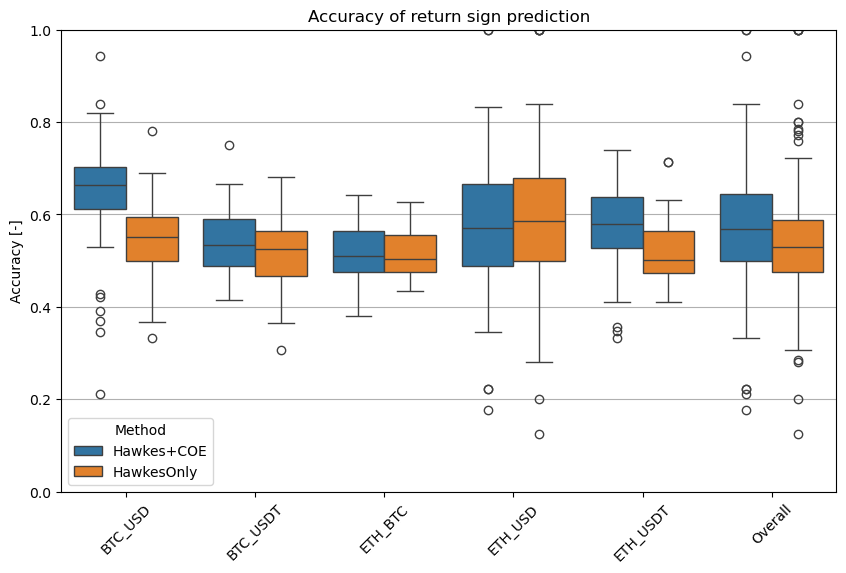

In [ ]:
df_final_copy = df_final.copy()
df_final_copy["Pair"] = "Overall"

df_final_copy = pd.concat([df_final, df_final_copy], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.boxplot(
    x="Pair",
    y="Accuracy",
    data=df_final_copy,
    hue="Method",
    order=["BTC_USD", "BTC_USDT", "ETH_BTC", "ETH_USD", "ETH_USDT", "Overall"],
)

plt.title(f"Accuracy of return sign prediction")
plt.grid(axis="y")
plt.ylim(0, 1)
plt.ylabel("Accuracy [-]")
plt.xlabel("")
# rotate x labels
plt.xticks(rotation=45)
plt.show()

In [32]:
# get the median accuracy for each pair
df_final_copy[["Pair", "Method", "Accuracy"]].groupby(["Pair", "Method"]).median()

Accuracy
Pair     Method              
BTC_USD  Hawkes+COE  0.664502
         HawkesOnly  0.551503
BTC_USDT Hawkes+COE  0.534247
         HawkesOnly  0.526316
ETH_BTC  Hawkes+COE  0.510931
         HawkesOnly  0.502941
ETH_USD  Hawkes+COE  0.571429
         HawkesOnly  0.586538
ETH_USDT Hawkes+COE  0.579371
         HawkesOnly  0.501946
Overall  Hawkes+COE  0.567816
         HawkesOnly  0.529412

In [ ]:
# TRADING SIMULATION FOR ETH BTC file orderbook_changes_1713886484276_1713885547.tsv
# extract files for ETH_BTC pair when the accuracy is similar to the median accuracy of each method
df_eth_btc = df_final[df_final["Pair"] == "BTC_USD"]

median_acc = df_eth_btc.groupby("Method")["Accuracy"].median()

tolerance = 0.01
filtered_df = df_eth_btc[
    df_eth_btc.apply(
        lambda row: abs(row["Accuracy"] - median_acc[row["Method"]]) <= tolerance,
        axis=1,
    )
]
result_files = filtered_df["file"].tolist()

print(result_files)

['orderbook_changes_1705356920082_1705353442.tsv', 'orderbook_changes_1705364671663_1705361143.tsv', 'orderbook_changes_1705364671663_1705361990.tsv', 'orderbook_changes_1705364671663_1705361627.tsv', 'orderbook_changes_1705364671663_1705361990.tsv', 'orderbook_changes_1705364671663_1705361143.tsv', 'orderbook_changes_1705356920082_1705353805.tsv', 'orderbook_changes_1705356920082_1705353926.tsv', 'orderbook_changes_1705356920082_1705354047.tsv', 'orderbook_changes_1705356920082_1705355620.tsv', 'orderbook_changes_1705356920082_1705355983.tsv', 'orderbook_changes_1705356920082_1705354652.tsv', 'orderbook_changes_1705356920082_1705354531.tsv', 'orderbook_changes_1705364671663_1705361143.tsv', 'orderbook_changes_1705364671663_1705363321.tsv']


In [ ]:
lob_df = pd.read_csv(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\dati\\hawkes\\orderbook_changes\\BTC_USD\\orderbook_changes_1705364671663.tsv",
    sep="\t",
)


lob_df = lob_df[
    (lob_df["Timestamp"] >= 1705361143000 - 2000)
    & (lob_df["Timestamp"] <= 1705361143000 + 120000 - 2000)
]


lob_df["MidPrice"] = (lob_df["AskPrice1"] + lob_df["BidPrice1"]) / 2


lob_df["Return"] = (lob_df["MidPrice"] - lob_df["MidPrice"].shift(1)) / lob_df[
    "MidPrice"
].shift(1)


lob_df["time_for_plot"] = (lob_df["Timestamp"] - 1705361143000 - 2000) / 1000


lob_df["Capital"] = (lob_df["MidPrice"] / lob_df["MidPrice"].iloc[0]) * 1000


lob_df[lob_df["Return"] != 0]

,AskPrice1,AskSize1,AskPrice2,AskSize2,AskPrice3,AskSize3,AskPrice4,AskSize4,AskPrice5,AskSize5,...,BidSize23,BidPrice24,BidSize24,BidPrice25,BidSize25,Timestamp,MidPrice,Return,time_for_plot,Capital
18032,42531,0.008000,42532,0.009326,42535,0.094083,42538,0.497917,42539,0.161427,...,0.477808,42499.0,7.500000,42498.0,0.028380,1705361141007,42530.0,NaN,-3.993,1000.000000
18049,42531,0.008000,42538,0.027747,42543,0.300000,42544,0.470103,42546,0.034591,...,0.319465,42490.0,1.035100,42488.0,0.028380,1705361144861,42530.5,0.000012,-0.139,1000.011756
18054,42552,0.541680,42554,0.472997,42555,0.007047,42558,0.300000,42559,0.630000,...,0.028380,42493.0,0.800345,42491.0,1.082901,1705361145757,42543.0,0.000294,0.757,1000.305667
18055,42554,0.472997,42555,0.007047,42558,0.300000,42561,0.060900,42563,0.002580,...,0.800345,42491.0,1.082901,NaN,NaN,1705361146006,42546.5,0.000082,1.006,1000.387961
18056,42551,0.232951,42553,0.003000,42554,0.469997,42555,0.007047,42558,0.247000,...,0.028380,42493.0,0.800345,42491.0,1.082901,1705361146007,42545.0,-0.000035,1.007,1000.352692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18581,42539,0.122415,42543,1.158515,42544,0.158100,42545,0.664436,42546,0.300000,...,0.034685,42500.0,0.000060,42499.0,0.470590,1705361256764,42535.0,0.000082,111.764,1000.117564
18587,42543,1.128864,42544,0.158100,42545,1.278636,42546,0.300000,42548,0.048180,...,0.028380,42501.0,0.034685,42500.0,0.000060,1705361258122,42537.0,0.000047,113.122,1000.164590
18588,42542,0.300000,42543,1.361814,42544,0.158100,42545,1.278636,42546,0.300000,...,0.028380,42501.0,0.034685,42500.0,0.000060,1705361258341,42536.5,-0.000012,113.341,1000.152833
18595,42541,0.470137,42542,0.555781,42543,0.591699,42545,1.278636,42546,0.300000,...,0.034685,42500.0,0.000060,42499.0,2.093190,1705361259701,42536.0,-0.000012,114.701,1000.141077


In [ ]:
capital = 1000

trading_map = {
    "Method": ["Hawkes+BI", "HawkesOnly", "Hawkes+COE"],
    "Time": [0, 0, 0],
    "Portfolio Value": [1000, 1000, 1000],
}

for _, row in df_hawkes_bi_file.iterrows():
    if row["Correct Prediction"]:
        capital *= 1 + abs(row["Return"])  # Apply return if correct
    else:
        capital *= 1 - abs(row["Return"])  # Apply loss if incorrect

    trading_map["Method"].append("Hawkes+BI")
    trading_map["Time"].append(
        row["Real Event Time"] - df_hawkes_bi_file.iloc[0]["Real Event Time"] + 1
    )
    trading_map["Portfolio Value"].append(capital)

capital = 1000

for _, row in df_hawkes_only_file.iterrows():
    if row["Correct Prediction"]:
        capital *= 1 + abs(row["Return"])  # Apply return if correct
    else:
        capital *= 1 - abs(row["Return"])  # Apply loss if incorrect

    trading_map["Method"].append("HawkesOnly")
    trading_map["Time"].append(
        row["Real Event Time"] - df_hawkes_only_file.iloc[0]["Real Event Time"] + 1
    )
    trading_map["Portfolio Value"].append(capital)

capital = 1000

df_hawkes_coe_file_plt = df_hawkes_coe_file[
    df_hawkes_coe_file["real"] > df_hawkes_coe_file.iloc[0]["real"] + 1
].copy()
df_hawkes_coe_file_plt["real"] = df_hawkes_coe_file_plt["real"] - 130

for _, row in df_hawkes_coe_file_plt.iterrows():
    if row["sign_predicted"]:
        capital *= 1 + abs(row["Return"])  # Apply return if correct
    else:
        capital *= 1 - abs(row["Return"])  # Apply loss if incorrect

    trading_map["Method"].append("Hawkes+COE")
    trading_map["Time"].append(row["real"] - df_hawkes_coe_file_plt.iloc[0]["real"] + 1)
    trading_map["Portfolio Value"].append(capital)

trading_df = pd.DataFrame(trading_map)
trading_df.sort_values(by=["Time", "Method"], inplace=True)

trading_df.tail()

,Method,Time,Portfolio Value
284,Hawkes+COE,116.234,1001.176321
103,Hawkes+BI,116.287,999.506076
216,HawkesOnly,116.287,1000.011790
285,Hawkes+COE,117.157,1001.188091
217,HawkesOnly,117.406,1000.023545


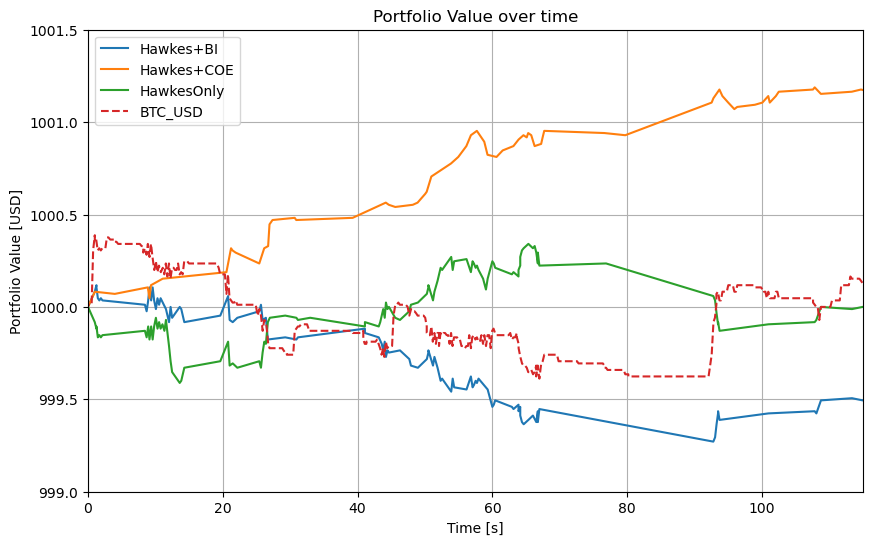

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="Time", y="Portfolio Value", data=trading_df, hue="Method")
sns.lineplot(
    x="time_for_plot", y="Capital", data=lob_df, label="BTC_USD", linestyle="--"
)
plt.title("Portfolio Value over time")
plt.xlabel("Time [s]")
plt.ylabel("Portfolio Value [USD]")
plt.ylim(999, 1001.5)
plt.xlim(0, 115)
plt.grid()
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define the directory you want to search in
directory = Path(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\coe_results"
)
files = [
    file for file in directory.rglob("*") if file.is_file() and "ETH_USD" in file.parts
]

best_strategy = {
    "ETH_USD": {
        "univariate_hawkes": "training_time_600",
        "multivariate_hawkes": "lshade_training_time_900",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "real_time",
    },
}
"""    "BTC_USDT": {
        "univariate_hawkes": "training_time_300",
        "multivariate_hawkes": "lshade_training_time_900",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "correct_time",
    },
    "ETH_BTC": {
        "univariate_hawkes": "training_time_300",
        "multivariate_hawkes": "lshade_training_time_900",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "correct_time",
    },
    
    "ETH_USDT": {
        "univariate_hawkes": "training_time_900",
        "multivariate_hawkes": "lshade_training_time_900",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "correct_time",
    },
}"""


def same_sign(a, b):
    return (a >= 0 and b >= 0) or (a < 0 and b < 0)


dfs = []
for file in files:
    fileparts = file.parts
    method = fileparts[-5]
    pair = fileparts[-4]
    param = fileparts[-3]
    bi_level = fileparts[-2]
    filename = fileparts[-1]

    if best_strategy[pair][method] != param:
        continue

    prediction_df = pd.read_csv(file, sep="\t")
    if method == "oracle":
        real_df = pd.read_csv(
            f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\simulation_dataframes\\filtered\\naive\\{pair}\\next_time_jump_seconds_ 1\\120\\{bi_level}\\{filename}",
            sep="\t",
        )
    else:
        real_df = pd.read_csv(
            f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\simulation_dataframes\\filtered\\{method}\\{pair}\\{param}\\120\\{bi_level}\\{filename}",
            sep="\t",
        )
    comparison_df = pd.concat([prediction_df, real_df], axis=1)
    comparison_df = comparison_df.dropna()

    comparison_df["sign_predicted"] = comparison_df[
        ["predicted_return", "Return"]
    ].apply(lambda x: same_sign(x["predicted_return"], x["Return"]), axis=1)
    df = comparison_df[["predicted_return", "sign_predicted", "Return"]].copy()
    df["error"] = (df["predicted_return"] - df["Return"]).abs()
    df["method"] = method
    df["pair"] = pair
    df["param"] = param
    df["bi_level"] = bi_level
    df["filename"] = filename

    dfs.append(df)

df = pd.concat(dfs)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\simulation_dataframes\\filtered\\moving_average\\ETH_USD\\window_duration_seconds_30\\120\\bi_level_10\\orderbook_changes_1711708129595_1711704564.tsv'

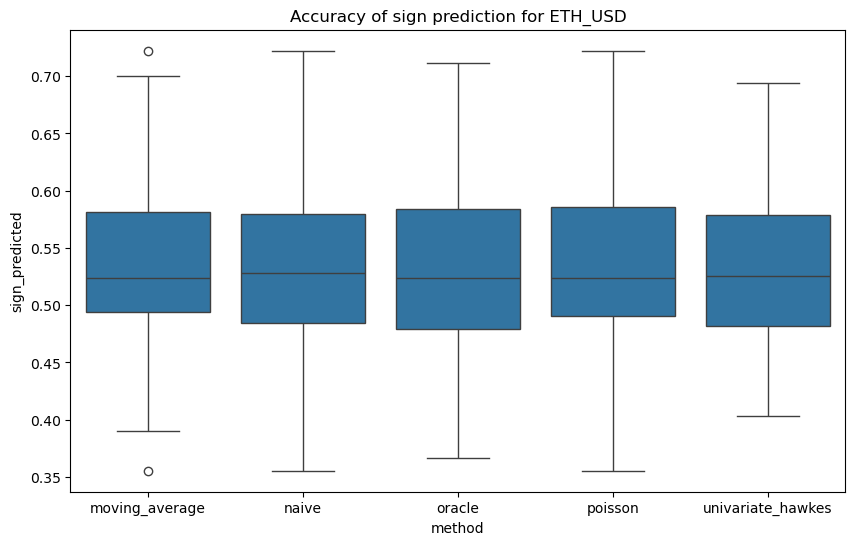

In [ ]:
for pair in df["pair"].unique():
    df_pair = df[df["pair"] == pair]
    df_accuracy = (
        df_pair[["method", "sign_predicted", "filename"]]
        .groupby(["method", "filename"])
        .mean()
    )
    df_accuracy = df_accuracy.reset_index()

    plt.figure(figsize=(10, 6))
    sns.boxplot(x="method", y="sign_predicted", data=df_accuracy)
    plt.title(f"Accuracy of sign prediction for {pair}")

In [ ]:
for pair in df["pair"].unique():
    df_pair = df[df["pair"] == pair]
    df_accuracy = (
        df_pair[["method", "sign_predicted", "filename"]]
        .groupby(["method", "filename"])
        .mean()
    )
    df_accuracy = df_accuracy.reset_index()

    plt.figure(figsize=(10, 6))
    sns.boxplot(x="method", y="sign_predicted", data=df_accuracy)
    plt.title(f"Accuracy of sign prediction for {pair}")